# Correlations between true and false memories

In [1]:
import re
import numpy as np
import pingouin as pg
import seaborn as sns
from scipy.stats import pearsonr
import statsmodels.api as sm
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
base_path = 'C:/Users\hchen\Dropbox\PycharmProjects/false_mem'

def check_correct(t, c):
    return np.nan if np.isnan(t) else (t == 1 and c == 0)
# Vectorize the function to apply it element-wise
vectorize_correct = np.vectorize(check_correct,otypes=[object])

def check_false(t, c):
    return np.nan if np.isnan(t) else (t == 0 or c == 1)
# Vectorize the function to apply it element-wise
vectorize_false = np.vectorize(check_false,otypes=[object])

C:\Users\hchen\AppData\Roaming\Python\Python39\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.4.0, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
C:\Users\hchen\AppData\Roaming\Python\Python39\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


## data cleaning: find recall count threshold for each story

pieman 70.16666666666667 20.891917629126876 38.82879022297636
2
eyespy 57.17777777777779 27.806704937949277 15.467720370853876
5
oregontrail 48.6875 22.551936585357808 14.859595121963286
2
baseball 47.94871794871795 22.6601974757149 13.9584217351456
1


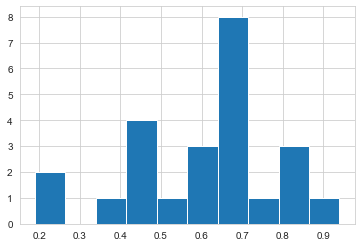

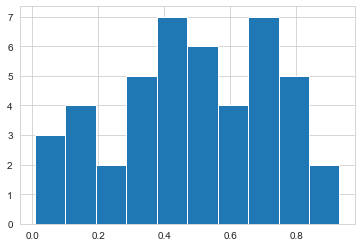

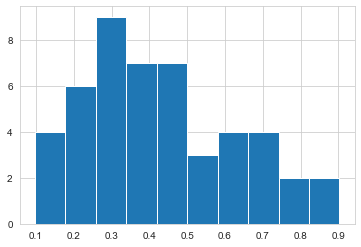

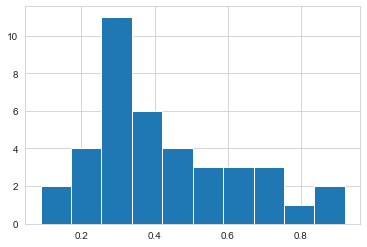

In [2]:
story_ids = ['pieman','eyespy','oregontrail','baseball']
subfolders = ['prompt8','prompt5b','prompt5','prompt1']
all_recall_count=[]
for story_id, subfolder in zip(story_ids, subfolders):
    recall_path = base_path+'/GPT_output/GPT_rating/%s_%s' % (story_id, subfolder)
    recall_paths = [recall_path + '/'+x
                    for x in os.listdir(recall_path) if 'prompt' not in x]
    story_segs = pd.read_excel('C:/Users/hchen\Dropbox\school_projects/2023/firebase_experiments\causality_rating\materials/story_segs.xlsx',
                               sheet_name='%s_segs' % story_id)['events'].to_list()

    match_path = 'C:/Users/hchen/Dropbox/PycharmProjects/false_mem/GPT_output/GPT_matching/%s' % story_id
    id_path = 'C:/Users/hchen\Dropbox\PycharmProjects\speech2text_topic\data\integrated/all_first_two.xlsx'
    id_sheet = pd.read_excel(id_path)
    SAVE_PATH = base_path+'/GPT_output/GPT_summary'
    confab = np.load(SAVE_PATH+'/confab_%s_%s.npy'%(story_id,subfolder))
    true = np.load(SAVE_PATH+'/conflict_%s_%s.npy'%(story_id,subfolder))
    # percentage recall
    percent_recall = []
    for i in range(len(story_segs)):
        percent_recall.append((len(recall_paths)-np.sum(np.logical_or(np.isnan(confab[:,i]),np.isnan(true[:,i]))))/len(recall_paths))
    all_recall_count.extend(np.array(percent_recall)*len(recall_paths))
    thr = np.mean(percent_recall)-1.5*np.std(percent_recall)
    print(story_id, np.mean(percent_recall)*len(recall_paths),np.std(percent_recall)*len(recall_paths), thr*len(recall_paths))

    print(np.sum(np.array(percent_recall)<thr))
    plt.figure()
    plt.hist(percent_recall)

54.256410256410255 25.21799108361386


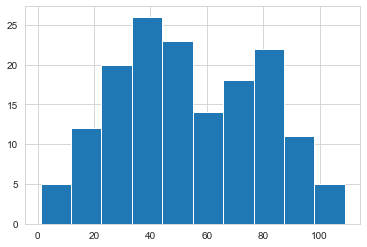

In [4]:
plt.hist(all_recall_count)
print(np.mean(all_recall_count),np.std(all_recall_count))

### load data and plot overview (percentage of recall and true/false counts for events)

pieman
removed event 0
eyespy
removed event 7
oregontrail
removed event 3
baseball
removed event 2


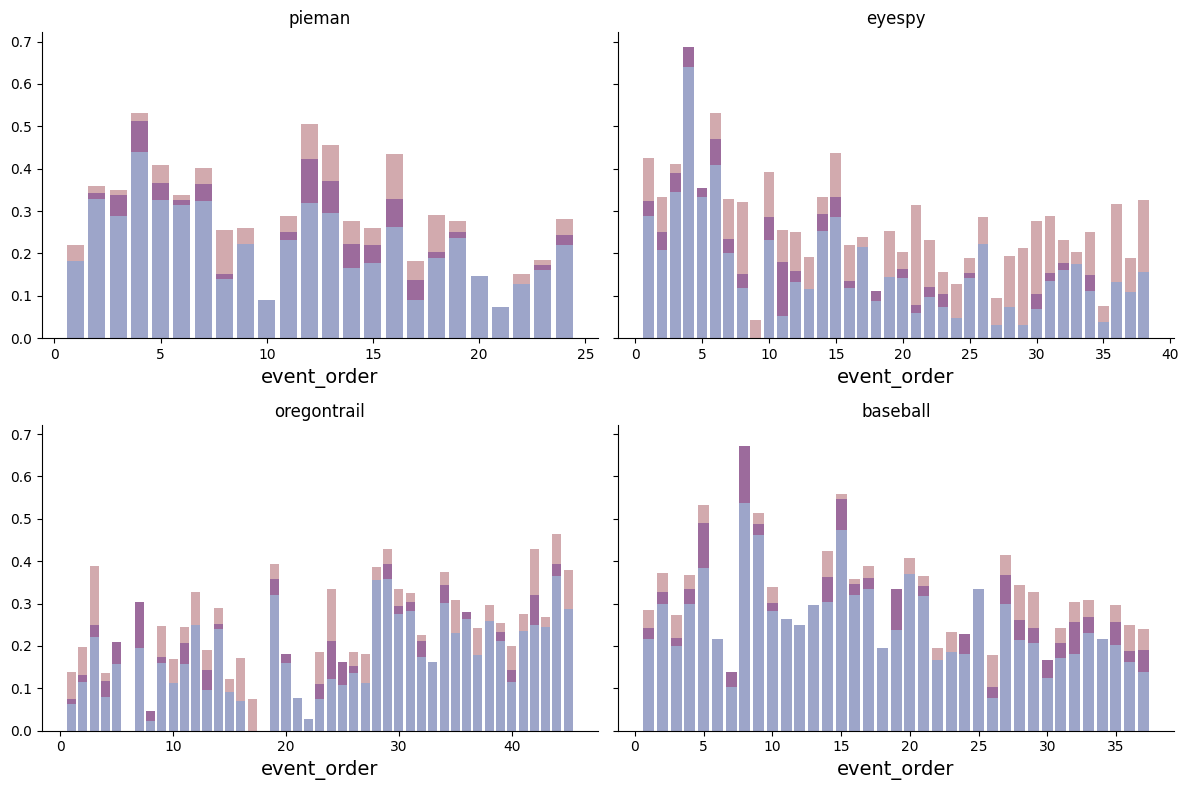

In [3]:
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
import matplotlib
matplotlib.rcParams.update(new_rc_params)
import matplotlib.pyplot as plt
THRESHOLD = 19 #number of recalls
story_ids = ['pieman','eyespy','oregontrail','baseball']
subfolders = ['prompt8','prompt5b','prompt5','prompt1']
axis = 0  # 0=event, 1=subject
arr_perc_false = []
arr_perc_correct = []
arr_perc_conflict = []
arr_perc_overlap = []
arr_perc_confab = []
arr_perc_recall = []
keep_ids = []
plt.style.use('default')
fig, axes = plt.subplots(2,2, figsize=(12, 8), sharey=True)
k = 0
for story_id, subfolder in zip(story_ids, subfolders):
    recall_path = base_path+'/GPT_output/GPT_rating/%s_%s' % (story_id, subfolder)
    recall_paths = [recall_path + '/'+x
                    for x in os.listdir(recall_path) if 'prompt' not in x]
    story_segs = pd.read_excel('C:/Users/hchen\Dropbox\school_projects/2023/firebase_experiments\causality_rating\materials/story_segs.xlsx',
                               sheet_name='%s_segs' % story_id)['events'].to_list()

    match_path = 'C:/Users/hchen/Dropbox/PycharmProjects/false_mem/GPT_output/GPT_matching/%s' % story_id
    id_path = 'C:/Users/hchen\Dropbox\PycharmProjects\speech2text_topic\data\integrated/all_first_two.xlsx'
    id_sheet = pd.read_excel(id_path)
    SAVE_PATH = base_path+'/GPT_output/GPT_summary'
    confab = np.load(SAVE_PATH+'/confab_%s_%s.npy'%(story_id,subfolder))
    true = np.load(SAVE_PATH+'/conflict_%s_%s.npy'%(story_id,subfolder))
    # percentage recall
    percent_recall = []
    for i in range(len(story_segs)):
        percent_recall.append((len(recall_paths)-np.sum(np.logical_or(np.isnan(confab[:,i]),np.isnan(true[:,i]))))/len(recall_paths))
    print(story_id)
    # plt.plot(np.arange(1,len(story_segs)+1),percent_recall,label='percent recall')
    # plt.legend()

    correct = vectorize_correct(true, confab).astype(float)
    false = vectorize_false(true,confab).astype(float)
    num_correct = np.nansum(correct,axis=axis)
    perc_correct = np.nansum(correct, axis=axis)/(np.array(percent_recall)*len(recall_paths))
    num_conflict = np.nansum(true==0, axis=axis)
    perc_conflict = np.nansum(true==0, axis=axis)/(np.array(percent_recall)*len(recall_paths))
    num_confab = np.nansum(confab==1, axis=axis)
    perc_confab = np.nansum(confab==1, axis=axis)/(np.array(percent_recall)*len(recall_paths))
    num_false = np.nansum(false, axis=axis)
    perc_false = num_false/(np.array(percent_recall)*len(recall_paths))
    # perc_false = num_false/len(recall_paths)
    perc_overlap = perc_confab+perc_conflict-perc_false

    """
    cleaning with threshold
    """
    keep_id = np.array(percent_recall)*len(recall_paths)>=THRESHOLD
    keep_ids.append(keep_id)
    print('removed event', len(percent_recall)-np.sum(keep_id))
    perc_false = perc_false[keep_id]
    perc_correct = perc_correct[keep_id]
    perc_conflict = perc_conflict[keep_id]
    perc_overlap = perc_overlap[keep_id]
    perc_confab = perc_confab[keep_id]
    percent_recall = np.array(percent_recall)[keep_id]
    
    arr_perc_false.append(perc_false)
    arr_perc_correct.append(perc_correct)
    arr_perc_conflict.append(perc_conflict)
    arr_perc_overlap.append(perc_overlap)
    arr_perc_confab.append(perc_confab)
    arr_perc_recall.append(percent_recall)
    """
    plot relative false
    """
    # create figure and axis objects with subplots()
    ax2 = axes.flat[k]
    # set x-axis label
    ax2.set_xlabel("event_order", fontsize=14)
    # make a plot with different y-axis using second axis object
    ax2.bar(np.arange(1, len(perc_false) + 1), perc_conflict+perc_confab-perc_overlap, color="#C0868C", alpha=0.7, edgecolor = "none",label='relative confab')
    ax2.bar(np.arange(1, len(perc_conflict) + 1), perc_conflict, color="#9c6b9c", alpha=1, edgecolor = "none",label='overlap')

    ax2.bar(np.arange(1, len(perc_conflict) + 1), perc_conflict-perc_overlap, color="#9da5c9", alpha=1,edgecolor = "none", label='relative conflicts')
    # ax2.bar(np.arange(1,len(story_segs)+1), np.nansum(confab==1,axis=0)+np.nansum(true==0,axis=0),color="red",alpha=0.3,label='number of confabulation')

    # ax2.set_ylabel("percentage", color="purple")
    ax2.set_title(story_id)
    ax2.spines[['right', 'top']].set_visible(False)
    k+=1
plt.tight_layout()
# plt.savefig("./relative_plot.svg")
plt.show()

# individual stories
# for perc_false, perc_correct, perc_conflict, perc_overlap, perc_confab in\
#    zip(arr_perc_false,arr_perc_correct,arr_perc_conflict,arr_perc_overlap,arr_perc_confab):
perc_false = np.concatenate(arr_perc_false)
perc_correct = np.concatenate(arr_perc_correct)
perc_conflict = np.concatenate(arr_perc_conflict)
perc_overlap = np.concatenate(arr_perc_overlap)
perc_confab = np.concatenate(arr_perc_confab)
perc_recall = np.concatenate(arr_perc_recall)

## histogram

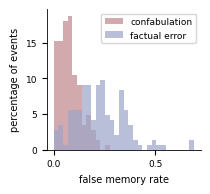

In [4]:
from matplotlib.ticker import FuncFormatter, MultipleLocator
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
import matplotlib
matplotlib.rcParams.update(new_rc_params)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(2.205,2.05))
# plt.title("Distribution of false memory rates", fontsize=7)
plt.xlabel("false memory rate", fontsize=7)
plt.ylabel("percentage of events", fontsize=7)
bins = np.histogram(np.hstack((perc_conflict,perc_confab)), bins=30)[1] 
plt.hist(perc_confab, bins, color="#C0868C",alpha=0.7, label='confabulation')
plt.hist(perc_conflict, bins, color="#9da5c9",alpha=0.7, label="factual error")
divisor = len(perc_conflict)
ax = plt.gca()
def to_percent(y, pos):
    return f"{(y/divisor)*100:.0f}"
ax.yaxis.set_major_formatter(FuncFormatter(to_percent))
ax.yaxis.set_major_locator(MultipleLocator(base=(divisor * 0.05))) 
plt.xticks(fontsize=6.5)
plt.yticks(fontsize=6.5)
plt.tight_layout() 
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)
plt.legend(fontsize=6.5)
ax.spines[['right', 'top']].set_visible(False)
#plt.savefig("C:/Users/hchen\Dropbox\PycharmProjects/false_mem/figures\svg/dist.svg")

In [11]:
# stats
from scipy.stats import ttest_rel,sem
print(ttest_rel(perc_conflict, perc_confab))
print(np.mean(perc_conflict), np.mean(perc_confab))
print(sem(perc_conflict), sem(perc_confab))
print(np.mean(perc_false), sem(perc_false))

TtestResult(statistic=13.689004415885611, pvalue=8.721866612015349e-28, df=143)
0.22610312320389092 0.07664629611905155
0.010405241143712406 0.004458029079477329
0.2760897860006108 0.010253939032285426


In [7]:
data_bars = np.zeros((4,3))  # stories x [conflict, confabulation, overlap]
k = 0
for false, recall, confab, conf, over \
    in zip(arr_perc_false, arr_perc_recall, arr_perc_confab, arr_perc_conflict, arr_perc_overlap):
    data_bars[k] = np.mean(conf-over), np.mean(confab-over), np.mean(over)
    k +=1

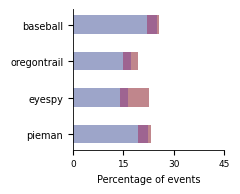

In [20]:
# four bars representing percentage
# Example data: [unrecalled, correct, conflict, confabulation, overlap]

labels = ['Factual Errors', 'Overlap', 'Confabulation']
colors = ['#9da5c9', '#9e6491', '#C0868C']

fig, ax = plt.subplots(figsize=(2.5, 2.05))
y_pos = np.arange(len(data_bars))
for i, (conf, confab, overlap) in enumerate(data_bars):
    x0 = 0
    conf_pure = conf - overlap
    confab_pure = confab - overlap
    
    # Plot segments
    for value, color, label in zip(
        [conf_pure, overlap, confab_pure],
        colors,
        labels
    ):
        ax.barh(i, value, left=x0, color=color, height=0.5,edgecolor='none', label=label if i == 0 else "")
        x0 += value

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(story_ids)
ax.set_xlim(0, 0.45)
ax.set_xticks([0,0.15,0.30,0.45])
ax.set_xticklabels([0,15,30,45])
ax.set_xlabel('Percentage of events',fontsize=7)
ax.tick_params(axis='x', labelsize=6.5)  # x-axis tick font size
ax.tick_params(axis='y', labelsize=7)
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig("C:/Users/hchen\Dropbox\PycharmProjects/false_mem/figures\svg/story_dist.svg")

## subject level distribution

In [5]:
# first two stories
axis = 1
event_n = 0
n_sub = 116
num_recall, num_conflict, num_confab, num_false, num_overlap = np.zeros(n_sub), np.zeros(n_sub), np.zeros(n_sub), np.zeros(n_sub), np.zeros(n_sub)
for story_id, subfolder in zip(story_ids[0:2], subfolders[0:2]):
    confab = np.load(SAVE_PATH+'/confab_%s_%s.npy'%(story_id,subfolder))
    true = np.load(SAVE_PATH+'/conflict_%s_%s.npy'%(story_id,subfolder))
    correct = vectorize_correct(true, confab).astype(float)
    false = vectorize_false(true,confab).astype(float)
    
    num_recall += confab.shape[1]-np.sum(np.logical_or(np.isnan(confab),np.isnan(true)), axis=axis)
    num_conflict += np.nansum(true==0, axis=axis)
    num_confab += np.nansum(confab==1, axis=axis)
    num_false += np.nansum(false, axis=axis)
    num_overlap += num_conflict+num_confab-num_false
    event_n += confab.shape[1]
rate_recall, rate_correct, rate_conflict, rate_confab, rate_false = num_recall/event_n, (num_recall-num_false)/num_recall,num_conflict/num_recall, num_confab/num_recall, num_false/num_recall
# last two stories
axis = 1
event_n = 0
n_sub = 113
num_recall, num_conflict, num_confab, num_false, num_overlap = np.zeros(n_sub), np.zeros(n_sub), np.zeros(n_sub), np.zeros(n_sub), np.zeros(n_sub)
for story_id, subfolder in zip(story_ids[2:], subfolders[2:]):
    confab = np.load(SAVE_PATH+'/confab_%s_%s.npy'%(story_id,subfolder))
    true = np.load(SAVE_PATH+'/conflict_%s_%s.npy'%(story_id,subfolder))
    correct = vectorize_correct(true, confab).astype(float)
    false = vectorize_false(true,confab).astype(float)
    
    num_recall += confab.shape[1]-np.sum(np.logical_or(np.isnan(confab),np.isnan(true)), axis=axis)
    num_conflict += np.nansum(true==0, axis=axis)
    num_confab += np.nansum(confab==1, axis=axis)
    num_false += np.nansum(false, axis=axis)
    num_overlap += num_conflict+num_confab-num_false
    event_n += confab.shape[1]
rate_recall2, rate_correct2, rate_conflict2, rate_confab2, rate_false2 = num_recall/event_n, (num_recall-num_false)/num_recall,num_conflict/num_recall, num_confab/num_recall, num_false/num_recall

In [6]:
# create df
rate_recall = np.concatenate([rate_recall,rate_recall2])
rate_correct = np.concatenate([rate_correct,rate_correct2])
rate_conflict = np.concatenate([rate_conflict,rate_conflict2])
rate_confab = np.concatenate([rate_confab,rate_confab2])
rate_false = np.concatenate([rate_false,rate_false2])
n_sub = 229
df_plot = pd.DataFrame({'label':np.concatenate([np.repeat('recall',n_sub),np.repeat('correct',n_sub), np.repeat('conflict',n_sub),np.repeat('confab',n_sub),np.repeat('false',n_sub)]),
                        'rate':np.concatenate([rate_recall,rate_correct,rate_conflict,rate_confab,rate_false])})


In [1]:
df_plot.to_excel(base_path+'/C. script_LMM/data_sheets/subject_distribution.xlsx')

NameError: name 'df_plot' is not defined

## raw count

pieman
removed event 0
eyespy
removed event 7
oregontrail
removed event 3
baseball
removed event 2


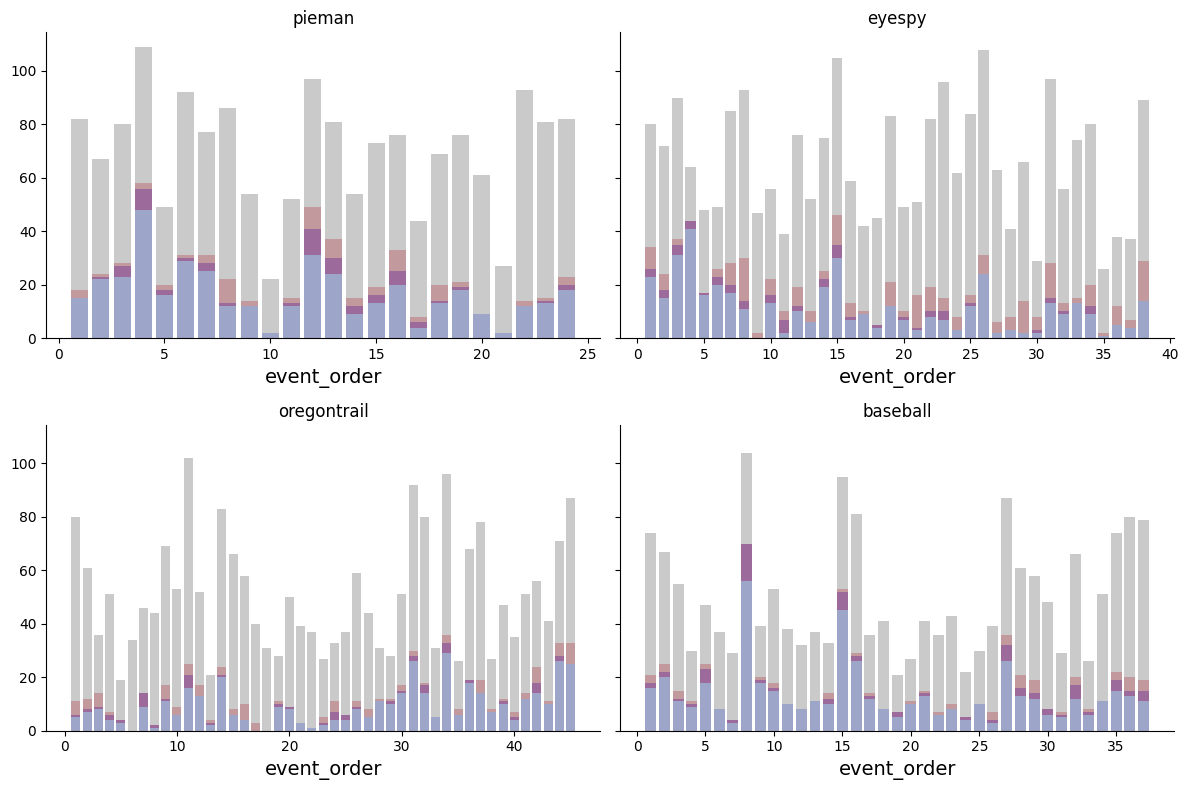

In [6]:
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
import matplotlib
matplotlib.rcParams.update(new_rc_params)
import matplotlib.pyplot as plt
THRESHOLD = 19 #number of recalls
story_ids = ['pieman','eyespy','oregontrail','baseball']
subfolders = ['prompt8','prompt5b','prompt5','prompt1']
axis = 0  # 0=event, 1=subject
arr_perc_false = []
arr_perc_correct = []
arr_perc_conflict = []
arr_perc_overlap = []
arr_perc_confab = []
arr_perc_recall = []
keep_ids = []
plt.style.use('default')
fig, axes = plt.subplots(2,2, figsize=(12, 8), sharey=True)
k = 0
for story_id, subfolder in zip(story_ids, subfolders):
    recall_path = base_path+'/GPT_output/GPT_rating/%s_%s' % (story_id, subfolder)
    recall_paths = [recall_path + '/'+x
                    for x in os.listdir(recall_path) if 'prompt' not in x]
    story_segs = pd.read_excel('C:/Users/hchen\Dropbox\school_projects/2023/firebase_experiments\causality_rating\materials/story_segs.xlsx',
                               sheet_name='%s_segs' % story_id)['events'].to_list()

    match_path = 'C:/Users/hchen/Dropbox/PycharmProjects/false_mem/GPT_output/GPT_matching/%s' % story_id
    id_path = 'C:/Users/hchen\Dropbox\PycharmProjects\speech2text_topic\data\integrated/all_first_two.xlsx'
    id_sheet = pd.read_excel(id_path)
    SAVE_PATH = base_path+'/GPT_output/GPT_summary'
    confab = np.load(SAVE_PATH+'/confab_%s_%s.npy'%(story_id,subfolder))
    true = np.load(SAVE_PATH+'/conflict_%s_%s.npy'%(story_id,subfolder))
    # percentage recall
    percent_recall = []
    for i in range(len(story_segs)):
        percent_recall.append((len(recall_paths)-np.sum(np.logical_or(np.isnan(confab[:,i]),np.isnan(true[:,i]))))/len(recall_paths))
    print(story_id)
    # plt.plot(np.arange(1,len(story_segs)+1),percent_recall,label='percent recall')
    # plt.legend()

    correct = vectorize_correct(true, confab).astype(float)
    false = vectorize_false(true,confab).astype(float)
    num_correct = np.nansum(correct,axis=axis)
    perc_correct = np.nansum(correct, axis=axis)/(np.array(percent_recall)*len(recall_paths))
    num_conflict = np.nansum(true==0, axis=axis)
    perc_conflict = np.nansum(true==0, axis=axis)/(np.array(percent_recall)*len(recall_paths))
    num_confab = np.nansum(confab==1, axis=axis)
    perc_confab = np.nansum(confab==1, axis=axis)/(np.array(percent_recall)*len(recall_paths))
    num_false = np.nansum(false, axis=axis)
    perc_false = num_false/(np.array(percent_recall)*len(recall_paths))
    # perc_false = num_false/len(recall_paths)
    perc_overlap = perc_confab+perc_conflict-perc_false
    #

    """
    cleaning with threshold
    """
    keep_id = np.array(percent_recall)*len(recall_paths)>=THRESHOLD
    keep_ids.append(keep_id)
    print('removed event', len(percent_recall)-np.sum(keep_id))
    perc_false = perc_false[keep_id]
    perc_correct = perc_correct[keep_id]
    perc_conflict = perc_conflict[keep_id]
    perc_overlap = perc_overlap[keep_id]
    perc_confab = perc_confab[keep_id]
    percent_recall = np.array(percent_recall)[keep_id]
    #    
    arr_perc_false.append(perc_false)
    arr_perc_correct.append(perc_correct)
    arr_perc_conflict.append(perc_conflict)
    arr_perc_overlap.append(perc_overlap)
    arr_perc_confab.append(perc_confab)
    arr_perc_recall.append(percent_recall)
    
    """
    plot absolute numbers
    """
    ax2 = axes.flat[k]
    # set x-axis label
    ax2.set_xlabel("event_order", fontsize=14)
    ax2.bar(np.arange(1, len(perc_false) + 1), np.array(percent_recall)*len(recall_paths), color="#B4B4B4", alpha=0.7, edgecolor = "none",label='number of recalls')
    ax2.bar(np.arange(1, len(perc_false) + 1), (perc_conflict+perc_confab-perc_overlap)*np.array(percent_recall)*len(recall_paths), color="#C0868C", alpha=0.7, edgecolor = "none",label='number of confab')
    ax2.bar(np.arange(1, len(perc_conflict) + 1), perc_conflict*np.array(percent_recall)*len(recall_paths), color="#9c6b9c", alpha=1, edgecolor = "none",label='overlap')
    ax2.bar(np.arange(1, len(perc_conflict) + 1), (perc_conflict-perc_overlap)*np.array(percent_recall)*len(recall_paths), color="#9da5c9", alpha=1,edgecolor = "none", label='number of conflicts')
    ax2.set_title(story_id)
    ax2.spines[['right', 'top']].set_visible(False)
    k+=1
plt.tight_layout()
plt.savefig("./absolute_plot.png")
plt.show()

# individual stories
# for perc_false, perc_correct, perc_conflict, perc_overlap, perc_confab in\
#    zip(arr_perc_false,arr_perc_correct,arr_perc_conflict,arr_perc_overlap,arr_perc_confab):
perc_false = np.concatenate(arr_perc_false)
perc_correct = np.concatenate(arr_perc_correct)
perc_conflict = np.concatenate(arr_perc_conflict)
perc_overlap = np.concatenate(arr_perc_overlap)
perc_confab = np.concatenate(arr_perc_confab)
perc_recall = np.concatenate(arr_perc_recall)

In [38]:
np.sum((true==0)[:,3])/len((true==0)[:,3])

0.3793103448275862

### correlation between true and conflicts

(-0.4085044490381041, 3.717718132729398e-07)
(-0.9340586667268563, 2.258189940894656e-65)
(0.09636241184710956, 0.2505778965987892)
(0.7728471852724396, 7.747762941595693e-30)


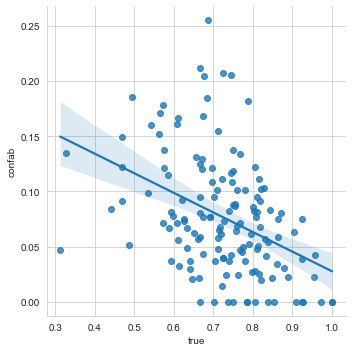

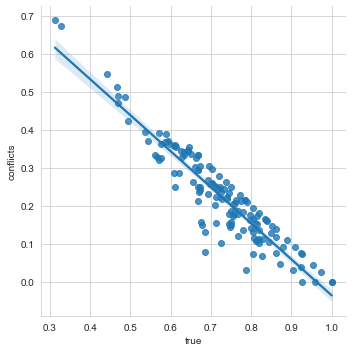

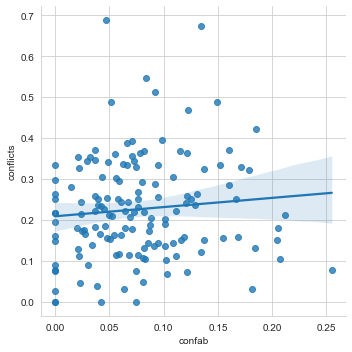

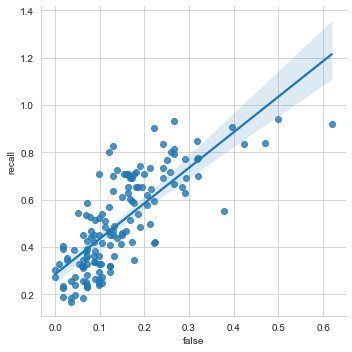

In [79]:
print(pearsonr(perc_confab,perc_correct))
print(pearsonr(perc_conflict,perc_correct))
print(pearsonr(perc_conflict,perc_confab))
print(pearsonr(perc_false,perc_recall))


sns.lmplot(y='confab',x='true',data=pd.DataFrame(data=dict(confab=perc_confab,true=perc_correct)))
plt.show()
sns.lmplot(y='conflicts',x='true',data=pd.DataFrame(data=dict(conflicts=perc_conflict,true=perc_correct)))
plt.show()
sns.lmplot(y='conflicts',x='confab',data=pd.DataFrame(data=dict(conflicts=perc_conflict,confab=perc_confab)))
plt.show()
sns.lmplot(y='recall',x='false',data=pd.DataFrame(data=dict(false=perc_false,recall=perc_recall)))
plt.show()

### partial correlation to test which error contributed more to this correlation

In [39]:
# Define new variables
total_colored = perc_confab + perc_conflict - perc_overlap
pure_red = perc_confab - perc_overlap  # red = confab
pure_green = perc_conflict - perc_overlap

# Calculate correlations
corr_total_colored_white, _ = pearsonr(total_colored, perc_correct)
corr_pure_red_white, _ = pearsonr(pure_red, perc_correct)
corr_pure_green_white, _ = pearsonr(pure_green, perc_correct)

# Prepare data for partial correlation
df = pd.DataFrame({
    'perc_correct': perc_correct,
    'pure_red': pure_red,
    'pure_green': pure_green,
    'perc_recall': perc_recall,
    'perc_false': perc_false
})

partial_corr_pure_red_white = \
pg.partial_corr(data=df, x='pure_red', y='perc_correct', covar='pure_green')['r'].values[0]
partial_corr_pure_green_white = \
pg.partial_corr(data=df, x='pure_green', y='perc_correct', covar='pure_red')['r'].values[0]

# Print results
print("Correlation between Total False and True:", corr_total_colored_white)
print("Correlation between Pure confab and True:", corr_pure_red_white)
print("Correlation between Pure conflicts and True:", corr_pure_green_white)
print("Partial Correlation between Pure Confab and True (controlling for Pure conflicts):", partial_corr_pure_red_white)
print("Partial Correlation between Pure Conflicts and True (controlling for Pure confab):", partial_corr_pure_green_white)


Correlation between Total False and True: 0.4612503822736229
Correlation between Pure confab and True: 0.4784448047935816
Correlation between Pure conflicts and True: 0.3563545344525407
Partial Correlation between Pure Confab and True (controlling for Pure conflicts): 0.4838495767139816
Partial Correlation between Pure Conflicts and True (controlling for Pure confab): 0.36452296085356994


## partial correlation (true x false) to remove the confound of total recall rate


           n         r        CI95%         p-val
pearson  154  0.927043  [0.9, 0.95]  3.272442e-66
                            OLS Regression Results                            
Dep. Variable:           perc_correct   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.919e+31
Date:                Mon, 24 Jun 2024   Prob (F-statistic):               0.00
Time:                        15:38:27   Log-Likelihood:                 5396.6
No. Observations:                 154   AIC:                        -1.079e+04
Df Residuals:                     151   BIC:                        -1.078e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

C:\Users\hchen\AppData\Roaming\Python\Python39\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  x = pd.concat(x[::order], 1)


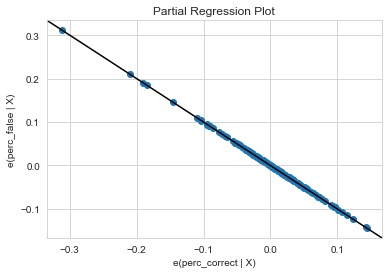

In [40]:
partial_corr_true_false = \
pg.partial_corr(data=df, x='perc_false', y='perc_correct', covar='perc_recall')
print(partial_corr_true_false)
## plot
# Define the dependent and independent variables
X = df[['perc_false', 'perc_recall']]
y = df['perc_correct']
# Add a constant to the independent variables
X = sm.add_constant(X)
# Fit the regression model
model = sm.OLS(y, X).fit()
print(model.summary())
# Partial regression plot for false recall
fig = sm.graphics.plot_partregress('perc_false', 'perc_correct', ['perc_recall'],
                                   data=df, obs_labels=False)
plt.show()

## Correlating precision (Heusser method) with percentage of recall

pieman (0.3787645817724249, 0.06797193146537754)


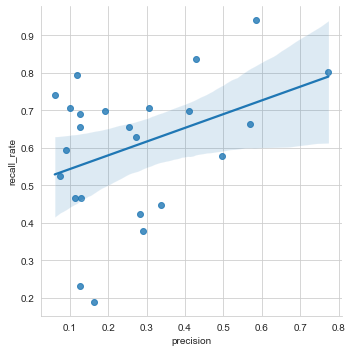

24 24
eyespy (0.334773831190216, 0.03993223801795908)


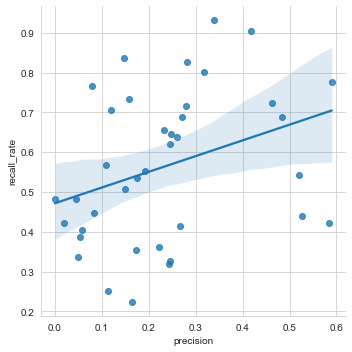

38 38
oregontrail (0.5838591405707693, 2.5520934597574295e-05)


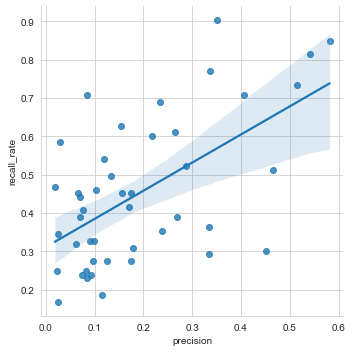

45 45
baseball (0.3937619147534525, 0.015897163291126132)


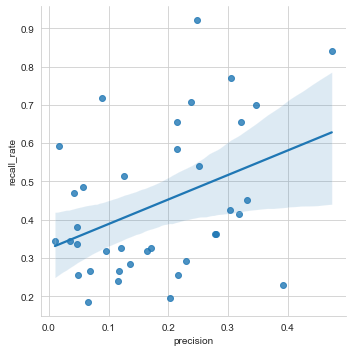

37 37


In [82]:
all_y = []
all_recall = []
for j, (story_id, subfolder) in enumerate(zip(story_ids, subfolders)):
        precisions = np.load(base_path+'/features/precisions_%s.npy' % story_id)
        y = np.mean(precisions,axis=0)
        if story_id=='oregontrail':
            y=y[0:-1]
        y = y[keep_ids[j]]
        try:
            print(story_id,pearsonr(arr_perc_recall[j], y))
            sns.lmplot(x='precision',y='recall_rate',data=pd.DataFrame(data=dict(precision=y,recall_rate=arr_perc_recall[j])))
            plt.show()
            all_y.extend(y)
            all_recall.extend(arr_perc_recall[j])
        except:
            pass
        print(len(y),len(arr_perc_recall[j]))

(0.46331767634906024, 4.9854671739059975e-09)


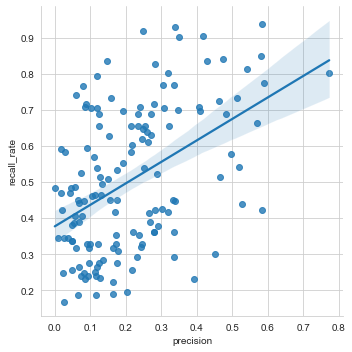

In [83]:
print(pearsonr(all_y, all_recall))
sns.lmplot(x='precision',y='recall_rate',data=pd.DataFrame(data=dict(precision=all_y,recall_rate=all_recall)))

## Correlating precision (Heusser method) with percentage of false memory


pieman (0.40562459340186874, 0.0492362605274336)


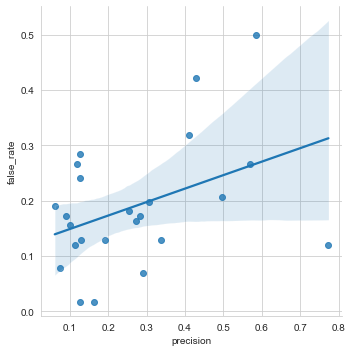

24 24
eyespy (0.3451900500451125, 0.020215040608259446)


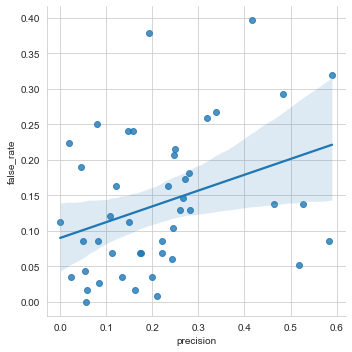

45 45
49 46
baseball (0.3719541982135113, 0.019720109903922547)


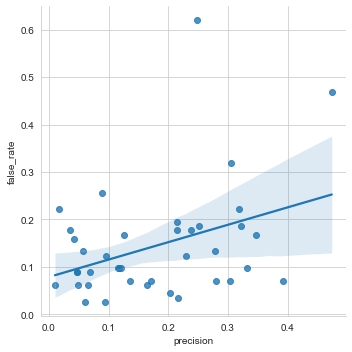

39 39


In [51]:
all_y = []
all_false = []
for j, (story_id, subfolder) in enumerate(zip(story_ids, subfolders)):
        precisions = np.load(base_path+'/features/precisions_%s.npy' % story_id)
        y = np.mean(precisions,axis=0)
        try:
            print(story_id,pearsonr(arr_perc_false[j], y))
            sns.lmplot(x='precision',y='false_rate',data=pd.DataFrame(data=dict(precision=y,false_rate=arr_perc_false[j])))
            plt.show()
            all_y.extend(y)
            all_false.extend(arr_perc_false[j])
        except:
            pass
        print(len(y),len(arr_perc_false[j]))

(0.3796722658045, 5.0654238255885324e-05)


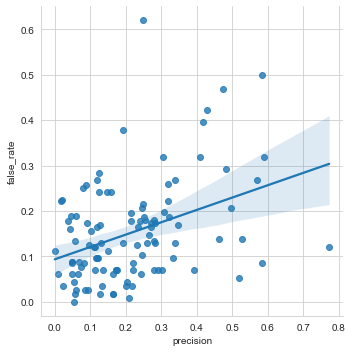

In [53]:
print(pearsonr(all_y, all_false))
sns.lmplot(x='precision',y='false_rate',data=pd.DataFrame(data=dict(precision=all_y,false_rate=all_false)))

## Correlating precision (Heusser method) with percentage of true memory


pieman (0.19609035339590736, 0.3584515605885184)


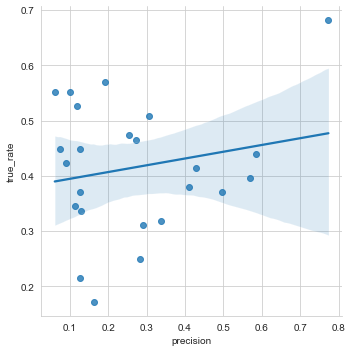

24 24
eyespy (0.3613091259013559, 0.014746863419766804)


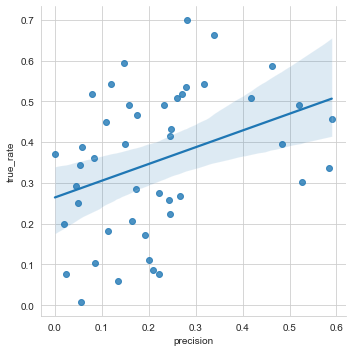

45 45
49 46
baseball (0.3634076721142163, 0.022965280932986845)


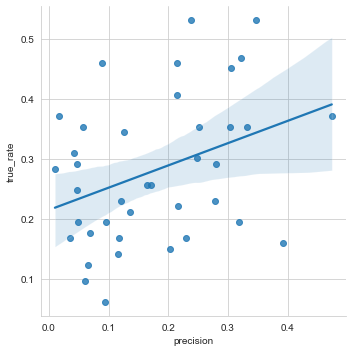

39 39


In [55]:
all_y = []
all_true = []
for j, (story_id, subfolder) in enumerate(zip(story_ids, subfolders)):
        precisions = np.load(base_path+'/features/precisions_%s.npy' % story_id)
        y = np.mean(precisions,axis=0)
        try:
            print(story_id,pearsonr(arr_perc_correct[j], y))
            sns.lmplot(x='precision',y='true_rate',data=pd.DataFrame(data=dict(precision=y,true_rate=arr_perc_correct[j])))
            plt.show()
            all_y.extend(y)
            all_true.extend(arr_perc_correct[j])
        except:
            pass
        print(len(y),len(arr_perc_correct[j]))

(0.3624923978947625, 0.00011560004398520372)


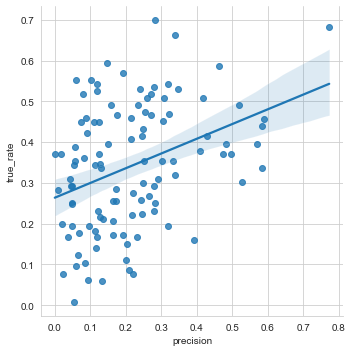

In [56]:
print(pearsonr(all_y, all_true))
sns.lmplot(x='precision',y='true_rate',data=pd.DataFrame(data=dict(precision=all_y,true_rate=all_true)))

## inspect specific events

In [78]:

story_ids = ['pieman','eyespy','oregontrail','baseball']
subfolders = ['prompt8','prompt5b','prompt5','prompt1']
subject_count = [116,116,113,115]
FALSE_COUNT = 0.17
for j, (story_id, subfolder, sub_count) in enumerate(zip(story_ids, subfolders, subject_count)):
    recall_counts = np.array(arr_perc_recall[j]*sub_count)
    false_counts = np.array(arr_perc_false[j]*arr_perc_recall[j]*sub_count)
    evs = np.where(false_counts > FALSE_COUNT*sub_count)[0]
    # inspect
    path = base_path+'/GPT_output/GPT_summary/inspect_%s_%s.xlsx' % (story_id, subfolder)
    inspect = pd.read_excel(path)
    print(story_id)
    for ev in evs:
        outputs = inspect.loc[(inspect.event_id==ev+1) & ((inspect.true==0) | (inspect.con==1)),'output']
        pattern = r"1\)\s(.*?)\s2\)\s(.*?)\s3\)"
        txt = 'Event Id: %s, %s out of %s false \n' % (ev+1, false_counts[ev], recall_counts[ev])
        # story segs
        story_segs = pd.read_excel(
        'C:/Users/hchen\Dropbox\school_projects/2023/firebase_experiments\causality_rating\materials/story_segs.xlsx',
        sheet_name='%s_segs' % story_id)['events'].to_list()
        txt += story_segs[ev]+'\n'
        # Applying the regex search
        error = ''
        for i in range(len(list(outputs))):
            match = re.search(pattern, list(outputs)[i].lower())
            error += match.group(1)+' '+match.group(2) + '\n'
        txt+=error
        txt+='\n\n'
        print(txt)

pieman
Event Id: 2, 24.0 out of 67.0 false 
And one day I’m walking toward the campus center and out comes the elusive Dean McGowan, architect of a policy to replace Fordham’s traditionally working- to middle-class students with wealthier, more prestigious ones. 
"journalism major" none.
"the dean is a really horrible person who nobody likes." none.
"there was going to be a talk by their new dean" none.
"regarding wage, student wages or working middle classes versus the admission rates" none.
"i guess he was standing in like a cafeteria sort of room" none.
"the dean of students" none.
"a question about admission rates and inflation" none.
"one night" none.
"he went to the dean's office" none.
"walking back from class" "he is part of the newspaper writing committee"
"he was working on middle-class students" none.
"the new dean" none.
"professor" none.
"dean mcdoward" none.
"which he hated and everyone else hated as well" none.
"dean magellan" none.
"principal" none.
"professor" none.
"j

In [73]:
outputs

0                 1) "journalism major" 2) None. 3) None.
17      1) "The dean is a really horrible person who n...
91      1) "there was going to be a talk by their new ...
160     1) "regarding wage, student wages or working m...
327     1) "I guess he was standing in like a cafeteri...
406           1) "the dean of students" 2) None. 3) None.
597     1) "a question about admission rates and infla...
633                      1) "one night" 2) None. 3) None.
750     1) "He went to the dean's office" 2) None. 3) ...
836     1) "walking back from class" 2) "he is part of...
911     1) "He was working on middle-class students" 2...
1027                  1) "the new dean" 2) None. 3) None.
1063                     1) "professor" 2) None. 3) None.
1206    1) "Dean McDoward" 2) None. 3) "students that ...
1235    1) "which he hated and everyone else hated as ...
1265                 1) "Dean Magellan" 2) None. 3) None.
1351                     1) "principal" 2) None. 3) None.
1369          

In [42]:
path = base_path+'/GPT_output/GPT_summary/inspect_%s_%s.xlsx' % (story_id, subfolder)
inspect = pd.read_excel(path)
for ev in evs:
    outputs = inspect.loc[(inspect.event_id==ev+1) & ((inspect.true==0) | (inspect.con==1)),'output']

In [65]:
pattern = r"1\)\s(.*?)\s2\)\s(.*?)\s3\)"
# Applying the regex search
match = re.search(pattern, list(outputs)[0].lower())
match.group(1)+' '+match.group(2)

In [67]:
match.group(1)

'"he said to come back the next day"'

In [76]:
recall_path = base_path+'/GPT_output/GPT_rating/%s_%s' % (story_id, subfolder)
recall_paths = [recall_path + '/'+x
                    for x in os.listdir(recall_path) if 'prompt' not in x]

In [77]:
print(recall_paths)

['C:/Users\\hchen\\Dropbox\\PycharmProjects/false_mem/GPT_output/GPT_rating/baseball_prompt1/P117_baseball.txt.xlsx', 'C:/Users\\hchen\\Dropbox\\PycharmProjects/false_mem/GPT_output/GPT_rating/baseball_prompt1/P118_baseball.txt.xlsx', 'C:/Users\\hchen\\Dropbox\\PycharmProjects/false_mem/GPT_output/GPT_rating/baseball_prompt1/P119_baseball.txt.xlsx', 'C:/Users\\hchen\\Dropbox\\PycharmProjects/false_mem/GPT_output/GPT_rating/baseball_prompt1/P120_baseball.txt.xlsx', 'C:/Users\\hchen\\Dropbox\\PycharmProjects/false_mem/GPT_output/GPT_rating/baseball_prompt1/P121_baseball.txt.xlsx', 'C:/Users\\hchen\\Dropbox\\PycharmProjects/false_mem/GPT_output/GPT_rating/baseball_prompt1/P122_baseball.txt.xlsx', 'C:/Users\\hchen\\Dropbox\\PycharmProjects/false_mem/GPT_output/GPT_rating/baseball_prompt1/P123_baseball.txt.xlsx', 'C:/Users\\hchen\\Dropbox\\PycharmProjects/false_mem/GPT_output/GPT_rating/baseball_prompt1/P124_baseball.txt.xlsx', 'C:/Users\\hchen\\Dropbox\\PycharmProjects/false_mem/GPT_output